In [2]:
import cfgrib
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import re
import glob
import pandas as pd
from matplotlib.cm import get_cmap

# Prepare datafiles for Anemoi
CERRA data is on a Lambert Conformal Conic (LCC) projected grid, not regular lat/lon. We download one with the surface variables and one with wind speed at the height levels. 

In [8]:
#Select only a box around the BOZ 
def index_box(ds, lat_min=51, lat_max=52, lon_min=2.0, lon_max=4):
    lat = ds["latitude"].values   # 2-D (y, x)
    lon = ds["longitude"].values  # 2-D (y, x)

    m = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    yy, xx = np.where(m)
    y0, y1 = int(yy.min()), int(yy.max())
    x0, x1 = int(xx.min()), int(xx.max())
    return slice(y0, y1 + 1), slice(x0, x1 + 1)

## Surface files 

In [5]:
datasets = cfgrib.open_datasets(
    "CERRA5_sfc.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

### Bind to BOZ 

In [6]:
cropped = []
for ds in datasets:
    ys, xs = index_box(ds)
    dsc = ds.isel(y=ys, x=xs)  # hard crop, no masking → no NaNs

    if "heightAboveGround" in dsc.coords and dsc.coords["heightAboveGround"].size == 1:
        dsc = dsc.reset_coords("heightAboveGround", drop=True)
        dsc=dsc.squeeze()

    cropped.append(dsc)

In [7]:
aligned = xr.align(*cropped, join="inner")  # keep only common coords (e.g., time)
ds = xr.merge(aligned, compat="override", combine_attrs="drop")

### Add forcings 

In [11]:
#Add sin and cosine of wind direction (at 10m) and sin and cosine of julian day 
dir_rad = np.deg2rad(ds["wdir10"])
sinwdir10 = np.sin(dir_rad).astype("float32").rename("sinwdir10")
coswdir10 = np.cos(dir_rad).astype("float32").rename("coswdir10")
year = ds["time"].dt.year
#2024 was a leap year
is_leap = ( (year % 4 == 0) )
year_len = xr.where(is_leap, 366, 365)

theta_doy = 2.0 * np.pi * (ds["time"].dt.dayofyear - 1) / year_len
sin_doy_1d = np.sin(theta_doy).astype("float32").rename("sin_doy")
cos_doy_1d = np.cos(theta_doy).astype("float32").rename("cos_doy")
sin_doy = sin_doy_1d.broadcast_like(ds["si10"])
cos_doy = cos_doy_1d.broadcast_like(ds["si10"])

ds = ds.assign(
    sinwdir10=sinwdir10,
    coswdir10=coswdir10,
    sin_doy=sin_doy,
    cos_doy=cos_doy,
)

### Save

In [13]:
ds.to_netcdf(
    "CERRA_sfc.nc",
    engine="netcdf4"
)

In [21]:
ds=xr.open_dataset("CERRA_sfc.nc")

In [22]:
ds

<xarray.Dataset> Size: 140MB
Dimensions:           (time: 5360, y: 22, x: 27)
Coordinates:
  * time              (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T21...
    step              timedelta64[ns] 8B ...
    entireAtmosphere  float64 8B ...
    latitude          (y, x) float64 5kB ...
    longitude         (y, x) float64 5kB ...
    valid_time        (time) datetime64[ns] 43kB ...
    meanSea           float64 8B ...
    surface           float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    mcc               (time, y, x) float32 13MB ...
    t2m               (time, y, x) float32 13MB ...
    si10              (time, y, x) float32 13MB ...
    wdir10            (time, y, x) float32 13MB ...
    msl               (time, y, x) float32 13MB ...
    sr                (time, y, x) float32 13MB ...
    orog              (time, y, x) float32 13MB ...
    sinwdir10         (time, y, x) float32 13MB ...
    coswdir10         (time, y, x) float32 13MB ...
    sin_doy           (time, y, x) float32 13MB ...
    cos_doy           (time, y, x) float32 13MB ...

### Plot outline

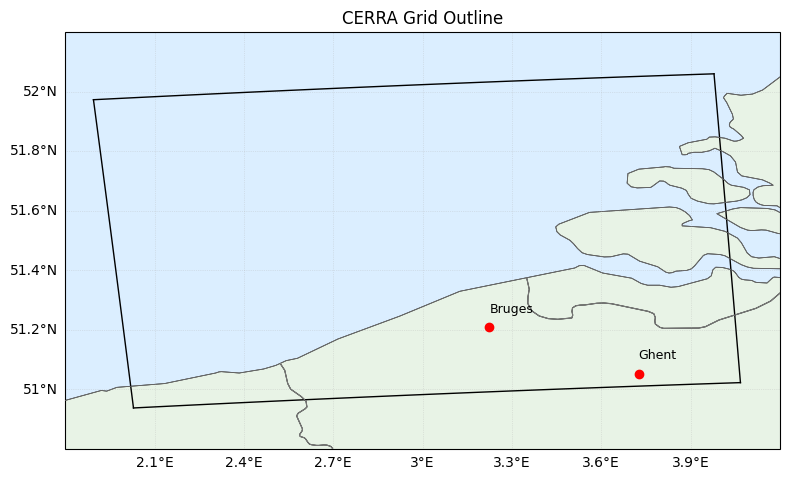

In [16]:
import cartopy.feature as cfeature

def plot_cerra_domain_with_belgium_box(
    ds, lat_min=51, lat_max=52, lon_min=2.0, lon_max=4.0,
    extent=(1.8, 4.2, 50.8, 52.2)
):
    lat = ds["latitude"].values
    lon = ds["longitude"].values

    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # --- Add background colors ---
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dbeeff", zorder=0)
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#e8f3e6", zorder=0)

    # Coastlines & borders on top
    ax.coastlines(resolution="10m", linewidth=0.6, color="black", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=2)
    gl = ax.gridlines(draw_labels=True, linestyle=":", linewidth=0.5, alpha=0.5)
    gl.top_labels = False; gl.right_labels = False

    # Belgium outline specifically (optional)
    countries = cfeature.NaturalEarthFeature(
        category="cultural", name="admin_0_countries", scale="10m", facecolor="none"
    )
    ax.add_feature(countries, edgecolor="gray", linewidth=0.5, zorder=3)

    # CERRA grid outline
    ax.plot(lon[0, :],  lat[0, :],  transform=ccrs.PlateCarree(), color="black", lw=1)
    ax.plot(lon[-1, :], lat[-1, :], transform=ccrs.PlateCarree(), color="black", lw=1)
    ax.plot(lon[:, 0],  lat[:, 0],  transform=ccrs.PlateCarree(), color="black", lw=1)
    ax.plot(lon[:, -1], lat[:, -1], transform=ccrs.PlateCarree(), color="black", lw=1)

    # Cities (lon, lat!)
    ax.plot(3.224167, 51.208889, "ro", markersize=6, transform=ccrs.PlateCarree())
    ax.text(3.224167, 51.208889+0.05, "Bruges", fontsize=9, color="black",
            transform=ccrs.PlateCarree())
    ax.plot(3.725278, 51.053611, "ro", markersize=6, transform=ccrs.PlateCarree())
    ax.text(3.725278, 51.053611+0.05, "Ghent", fontsize=9, color="black",
            transform=ccrs.PlateCarree())

    ax.set_title("CERRA Grid Outline")
    plt.tight_layout()
    plt.show()

plot_cerra_domain_with_belgium_box(ds)

## Level heigts files

In [17]:
ds_height = cfgrib.open_datasets(
    "Cerra_height.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [18]:
cropped_height = []
for ds in ds_height:
    ys, xs = index_box(ds)
    dsc = ds.isel(y=ys, x=xs)  # hard crop, no masking → no NaNs

    if "heightAboveGround" in dsc.coords and dsc.coords["heightAboveGround"].size == 1:
        dsc = dsc.reset_coords("heightAboveGround", drop=True)
        dsc=dsc.squeeze()

    cropped_height.append(dsc)

In [19]:
aligned = xr.align(*cropped_height, join="inner")  # keep only common coords (e.g., time)
ds_h = xr.merge(aligned, compat="override", combine_attrs="drop")

In [24]:
#turn the height variables into seperate variables, easier for Anemoi 
new_vars = {}

for h in ds_h.heightAboveGround.values:
    h_int = int(h)  # e.g. 50.0 -> 50
    
    # Extract wind speed and direction
    ws = ds_h["ws"].sel(heightAboveGround=h)
    wdir = ds_h["wdir"].sel(heightAboveGround=h)
    
    # Rename speed and direction
    new_vars[f"ws{h_int}"] = ws.rename(f"ws{h_int}")
    new_vars[f"wdir{h_int}"] = wdir.rename(f"wdir{h_int}")
    
    # Compute sin/cos of direction (convert deg -> rad first)
    dir_rad = np.deg2rad(wdir)
    new_vars[f"sinwdir{h_int}"] = np.sin(dir_rad).astype("float32").rename(f"sinwdir{h_int}")
    new_vars[f"coswdir{h_int}"] = np.cos(dir_rad).astype("float32").rename(f"coswdir{h_int}")

# Merge into a single dataset
ds_h_expanded = xr.merge(list(new_vars.values()), compat="override", combine_attrs="drop")

<xarray.Dataset> Size: 204MB
Dimensions:            (time: 5360, y: 22, x: 27)
Coordinates:
  * time               (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T2...
    step               timedelta64[ns] 8B 00:00:00
    heightAboveGround  float64 8B 50.0
    latitude           (y, x) float64 5kB 50.94 50.94 50.95 ... 52.06 52.06
    longitude          (y, x) float64 5kB 2.029 2.108 2.186 ... 3.898 3.978
    valid_time         (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T2...
Dimensions without coordinates: y, x
Data variables: (12/16)
    ws50               (time, y, x) float32 13MB ...
    wdir50             (time, y, x) float32 13MB 208.6 209.1 ... 244.6 244.9
    sinwdir50          (time, y, x) float32 13MB -0.479 -0.4866 ... -0.9057
    coswdir50          (time, y, x) float32 13MB -0.8778 -0.8736 ... -0.424
    ws100              (time, y, x) float32 13MB ...
    wdir100            (time, y, x) float32 13MB 209.3 209.8 ... 244.1 244.5
    ...                 ...
    sinwdir150         (time, y, x) float32 13MB -0.4967 -0.505 ... -0.9012
    coswdir150         (time, y, x) float32 13MB -0.8679 -0.8631 ... -0.4335
    ws200              (time, y, x) float32 13MB ...
    wdir200            (time, y, x) float32 13MB 210.3 210.9 ... 243.6 244.3
    sinwdir200         (time, y, x) float32 13MB -0.5047 -0.5132 ... -0.9009
    coswdir200         (time, y, x) float32 13MB -0.8633 -0.8583 ... -0.4339

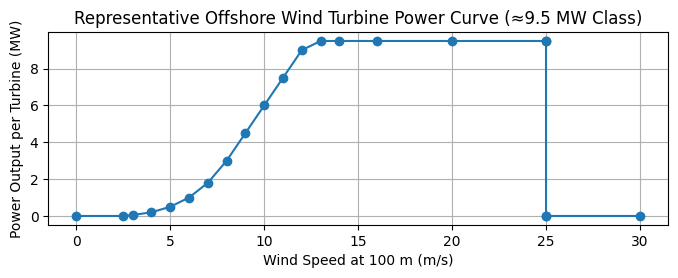

In [25]:
#add synthetic wind power with a power curve 
ws_pts = np.array([0.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                   11.0, 12.0, 13.0, 14.0, 16.0, 20.0, 24.99,24.999,25.0,25.01, 30.0], dtype="float32")
p_pts  = np.array([0.0, 0.0, 0.05, 0.20, 0.50, 1.00, 1.80, 3.00, 4.50, 6.00,
                   7.50, 9.00, 9.50, 9.50, 9.50, 9.50, 9.5,9.5,0.00,0.00, 0.00], dtype="float32")
plt.figure(figsize=(8, 2.5))
plt.plot(ws_pts, p_pts, marker='o', linestyle='-')
plt.xlabel("Wind Speed at 100 m (m/s)")
plt.ylabel("Power Output per Turbine (MW)")
plt.title("Representative Offshore Wind Turbine Power Curve (≈9.5 MW Class)")
plt.grid(True)
plt.show()

In [26]:
def interp_power(ws):
    return np.interp(ws, ws_pts, p_pts)

In [28]:
wind_power = xr.apply_ufunc(
    np.interp,                          # call NumPy directly
    ds_h_expanded["ws100"],
    kwargs={"xp": ws_pts, "fp": p_pts, "left": 0.0, "right": 0.0},
    input_core_dims=[[]],
    output_core_dims=[[]],
    vectorize=True,                     
    dask="parallelized",               
    output_dtypes=[ds_h_expanded["ws100"].dtype],  
).rename("wind_power")
wind_power.attrs = {}

ds_h_expanded = ds_h_expanded.assign(wind_power=wind_power)

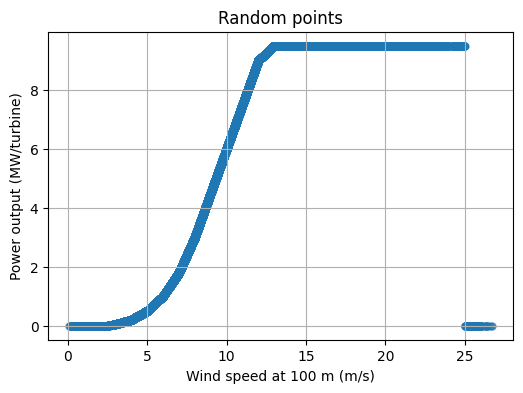

In [29]:
#SANITY CHECK
x=ds_h_expanded["ws100"].isel(time=slice(0,500)).isel(y=slice(0,10)).isel(x=slice(0,10))
y=ds_h_expanded["wind_power"].isel(time=slice(0,500)).isel(y=slice(0,10)).isel(x=slice(0,10))
ws_flat = x.values.ravel()
wp_flat = y.values.ravel()
mask = np.isfinite(ws_flat) & np.isfinite(wp_flat)
ws_flat = ws_flat[mask]; wp_flat = wp_flat[mask]

rng = np.random.default_rng(42)
n = min(100, ws_flat.size)
idx = rng.choice(ws_flat.size, size=n, replace=False)

plt.figure(figsize=(6,4))
plt.scatter(ws_flat, wp_flat, s=25, alpha=0.7)
plt.xlabel("Wind speed at 100 m (m/s)")
plt.ylabel("Power output (MW/turbine)")
plt.title(f"Random points")
plt.grid(True)
plt.show()

### Save 

In [30]:
ds_h_expanded.to_netcdf(
    "CERRA_height.nc",
    engine="netcdf4"
)

## Merge surface and height datasets 

In [45]:
#Sanity check 
ds_sfc=xr.open_dataset("CERRA_sfc.nc")
ds_sfc=ds_sfc.rename({"si10": "ws10"})
#ds_sfc

In [46]:
#Sanity check 
ds_height=xr.open_dataset("CERRA_height.nc")
#ds_height 

In [47]:
#sanity check
nan_counts = {var: ds_sfc[var].isnull().sum().item() for var in ds_sfc.data_vars}
print(nan_counts)

{'mcc': 0, 't2m': 0, 'ws10': 0, 'wdir10': 0, 'msl': 0, 'sr': 0, 'orog': 0, 'sinwdir10': 0, 'coswdir10': 0, 'sin_doy': 0, 'cos_doy': 0}


In [48]:
#sanity check
nan_counts = {var: ds_height[var].isnull().sum().item() for var in ds_height.data_vars}
print(nan_counts)

{'ws50': 0, 'wdir50': 0, 'sinwdir50': 0, 'coswdir50': 0, 'ws100': 0, 'wdir100': 0, 'sinwdir100': 0, 'coswdir100': 0, 'ws150': 0, 'wdir150': 0, 'sinwdir150': 0, 'coswdir150': 0, 'ws200': 0, 'wdir200': 0, 'sinwdir200': 0, 'coswdir200': 0, 'wind_power': 0}


In [49]:
ds_boz = xr.merge([ds_sfc, ds_height], compat="override", combine_attrs="drop")

In [51]:
ds_boz.to_netcdf(
    "CERRA_BOZ.nc",
    engine="netcdf4"
)

In [53]:
#sanity check 
#xr.open_dataset("CERRA_BOZ.nc")